Dataset Loaded Successfully!
Shape: (1000, 10)
            brand                                              title  \
0            Dior  Christian Dior Sauvage Men's EDP 3.4 oz Fragra...   
1         AS SHOW  A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...   
2       Unbranded                   HOGO BOSS cologne For Men 3.4 oz   
3  Giorgio Armani  Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...   
4         Lattafa  Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...   

              type   price priceWithCurrency  available  \
0    Eau de Parfum   84.99      US $84.99/ea       10.0   
1    Eau de Parfum  109.99        US $109.99        8.0   
2  Eau de Toilette  100.00        US $100.00       10.0   
3  Eau de Toilette     NaN      US $44.99/ea        2.0   
4       Fragrances   16.91         US $16.91        NaN   

                           availableText   sold                lastUpdated  \
0      More than 10 available / 116 sold  116.0  May 24, 2024 10:03:04 PDT   
1        

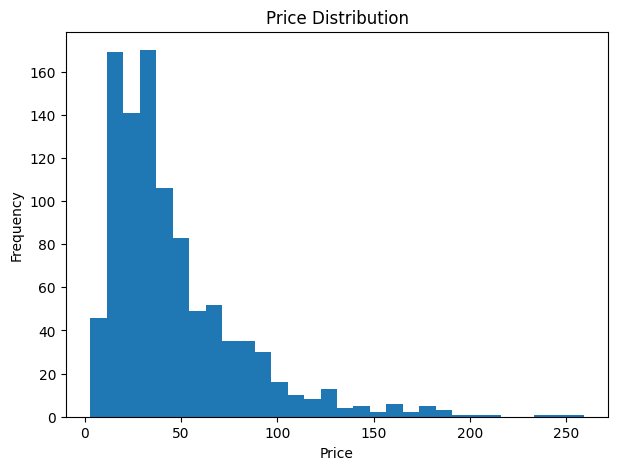

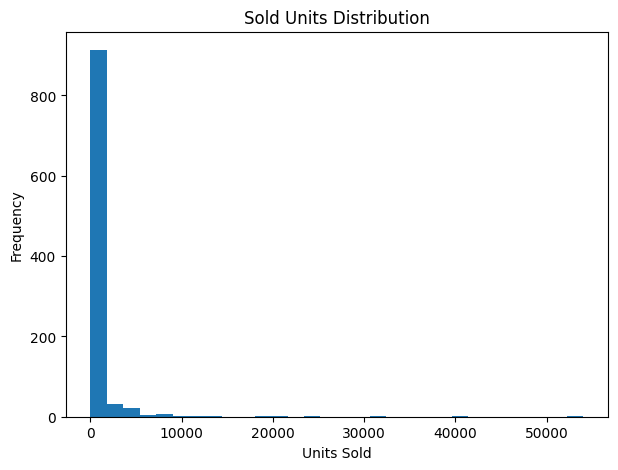

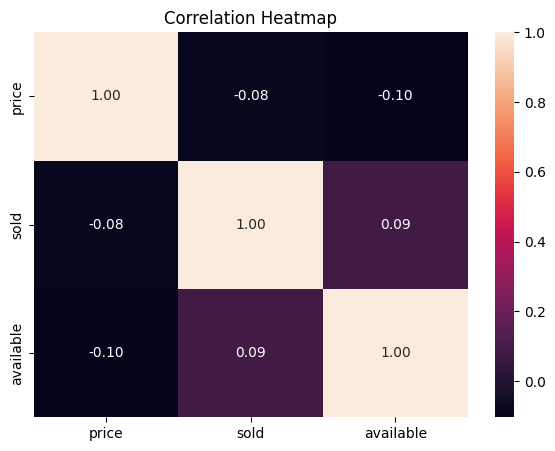


Explained Variance by PCA: 35.45%


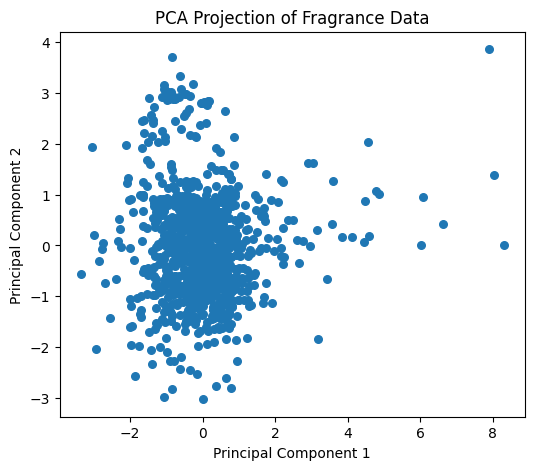

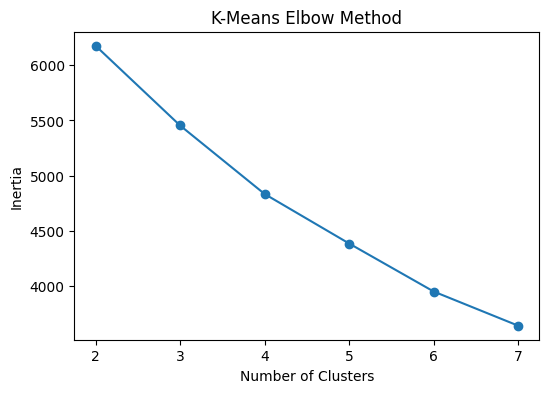

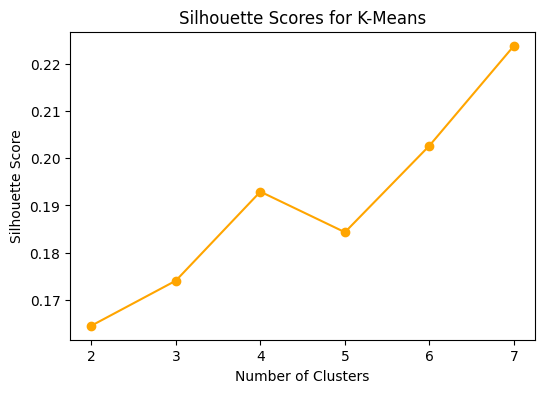

Optimal number of clusters (K-Means): 7
KMeans --> Silhouette: 0.224 | Davies-Bouldin: 1.293
Hierarchical --> Silhouette: 0.169 | Davies-Bouldin: 1.280
DBSCAN --> Silhouette: 0.327 | Davies-Bouldin: 2.509

Best Performing Model: Hierarchical


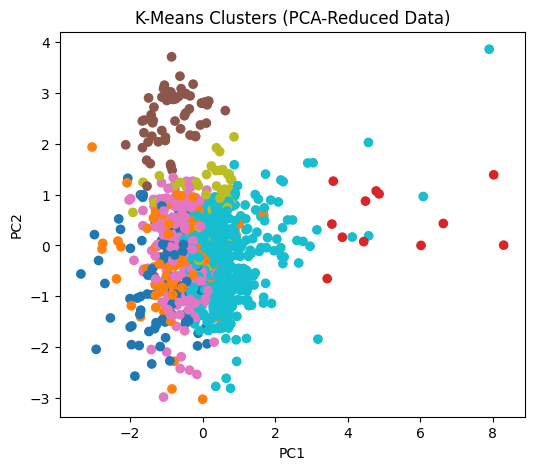


--- Cluster Characteristics ---
              brand       type       price   available         sold  \
Cluster                                                               
0        123.564815  27.009259  121.683426    5.361111   178.810185   
1        132.788235  26.729412   42.272824   14.541176   207.682353   
2        131.833333  28.500000   25.522500  463.500000  3244.500000   
3        197.969231  52.000000   35.407385    8.369231   139.992308   
4        115.612069  25.482759   35.634655    7.793103   127.838362   
5         81.534483  46.431034   43.504483    4.448276    71.155172   
6        118.084091  26.743182   37.154432   17.804545  1461.778409   

         days_since_update  itemLocation  
Cluster                                   
0               519.527778    118.629630  
1               532.741176    103.552941  
2               518.833333     52.000000  
3               520.661538    174.615385  
4               519.706897    194.935345  
5               518.810345

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Fragrance Dataset - COM7022 - [4037].csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
print(df.dtypes)

# Exploratory Data Analysis (EDA)
plt.figure(figsize=(7,5))
plt.hist(df['price'].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(df['sold'].dropna(), bins=30)
plt.title("Sold Units Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

numeric_cols = df[['price', 'sold']].copy()
numeric_cols['available'] = df['available'].astype(str)
numeric_cols['available'] = numeric_cols['available'].str.replace('[^0-9]', '', regex=True)
numeric_cols['available'] = numeric_cols['available'].replace('', np.nan).astype(float)
numeric_cols['available'] = numeric_cols['available'].fillna(0)

plt.figure(figsize=(7,5))
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# ---- Price Cleaning ----
if 'priceWithCurrency' in df.columns:
    df['price'] = df['priceWithCurrency'].replace('[^0-9.]', '', regex=True).astype(float)

df['price'] = df['price'].fillna(df['price'].median())
df['sold'] = df['sold'].fillna(df['sold'].median())

def clean_available(val):
    try:
        if pd.notna(val) and str(val).replace('.', '', 1).isdigit():
            return int(float(val))
        val = str(val).strip().lower()
        if val in ['true', 'yes', 'available', 'in stock', '1']:
            return 1
        elif val in ['false', 'no', 'out of stock', '0']:
            return 0
        else:
            return np.nan
    except:
        return np.nan

df['available'] = df['available'].apply(clean_available)
df['available'] = df['available'].fillna(0).astype(int)

df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')
df['days_since_update'] = (pd.Timestamp.today() - df['lastUpdated']).dt.days
df['days_since_update'] = df['days_since_update'].fillna(df['days_since_update'].median())

features = ['brand', 'type', 'price', 'available', 'sold', 'days_since_update', 'itemLocation']
df_selected = df[features].copy()

cat_cols = ['brand', 'type', 'itemLocation']
encoder = LabelEncoder()
for col in cat_cols:
    df_selected[col] = encoder.fit_transform(df_selected[col].astype(str))

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
print(f"\nExplained Variance by PCA: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(6,5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], s=30)
plt.title("PCA Projection of Fragrance Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

inertias, sil_scores = [], []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_data, kmeans.labels_))

plt.figure(figsize=(6,4))
plt.plot(range(2,8), inertias, marker='o')
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(2,8), sil_scores, marker='o', color='orange')
plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

best_k = np.argmax(sil_scores) + 2
print(f"Optimal number of clusters (K-Means): {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

hier_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hier_model.fit_predict(scaled_data)

dbscan_model = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan_model.fit_predict(scaled_data)

def evaluate_model(name, labels, data):
    if len(set(labels)) > 1:
        sil = silhouette_score(data, labels)
        dbi = davies_bouldin_score(data, labels)
    else:
        sil, dbi = 0, np.inf
    print(f"{name} --> Silhouette: {sil:.3f} | Davies-Bouldin: {dbi:.3f}")
    return sil, dbi

scores = {}
scores['KMeans'] = evaluate_model("KMeans", kmeans_labels, scaled_data)
scores['Hierarchical'] = evaluate_model("Hierarchical", hier_labels, scaled_data)
scores['DBSCAN'] = evaluate_model("DBSCAN", db_labels, scaled_data)

best_model = min(scores, key=lambda k: scores[k][1])
print(f"\nBest Performing Model: {best_model}")

plt.figure(figsize=(6,5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=kmeans_labels, cmap='tab10')
plt.title("K-Means Clusters (PCA-Reduced Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

df_clusters = df_selected.copy()
df_clusters['Cluster'] = kmeans_labels

cluster_summary = df_clusters.groupby('Cluster').mean()
print("\n--- Cluster Characteristics ---")
print(cluster_summary)

df['Cluster'] = kmeans_labels
df.to_csv("Fragrance_Clustered_Output.csv", index=False)
print("\nClustered dataset exported as 'Fragrance_Clustered_Output.csv'")
